# Time series analysis

Casual analysis of time series, with an emphasis on exploring a broad range of methods and techniques for self-learning purposes, rather than on outputting useful results or a coherent narrative/story.

_Techniques explored:_ PCA, Gradient Boosting, LSTM, ...

_Statistical concepts and tests explored:_ Skewness and kurtosis for distribution shape, Augmented Dickey–Fuller (ADF) and Kwiatkowski–Phillips–Schmidt–Shin (KPSS) tests for stationarity, correlation matrix, ...

_Financial concepts explored:_ Volatility, returns, volatility clustering,  ...

dataset found here https://github.com/laiguokun/multivariate-time-series-data

The dataset is the exchange rates of the national currencies of Australia, the UK, Canada, Switzerland, China, Japan, New Zealand and Singapore (with respect to the US dollar I guess).

---

**1- Visualization**

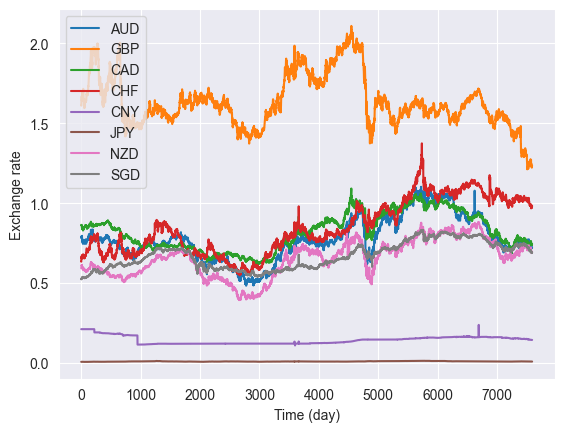

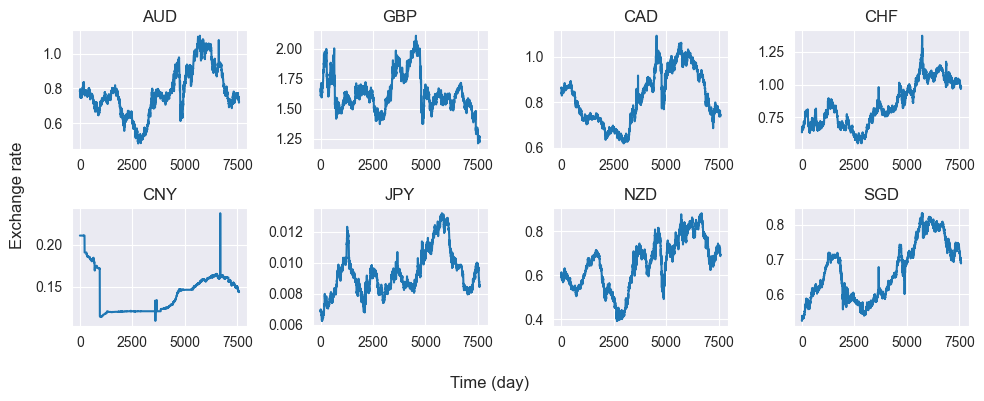

In [106]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import gzip
import numpy as np
import matplotlib.pyplot as plt

#-----------------------# loading the data #-------------------------#
f = gzip.open("exchange_rate.txt.gz", "rt")
data = np.array([[float(x) for x in line.split(",")] for line in f])
labels = ["AUD", "GBP", "CAD", "CHF", "CNY", "JPY", "NZD", "SGD"]
#--------------------------------------------------------------------#


#-----------------------# plotting the data #------------------------#
plt.figure()
labels = ["AUD", "GBP", "CAD", "CHF", "CNY", "JPY", "NZD", "SGD"]
plt.plot(data)
plt.xlabel("Time (day)")
plt.ylabel("Exchange rate")
plt.legend(labels)


# 1 time series per panel
fig, axes = plt.subplots(2, 4, figsize=(10, 4))
axes = axes.ravel()

for i in range(8):
    axes[i].plot(data[:, i])
    axes[i].set_title(labels[i])


fig.supxlabel("Time (day)")
fig.supylabel("Exchange rate")
figsize=(10, 10)

plt.tight_layout()
plt.show()
#--------------------------------------------------------------------#

---

**2- Simple descriptive analysis**

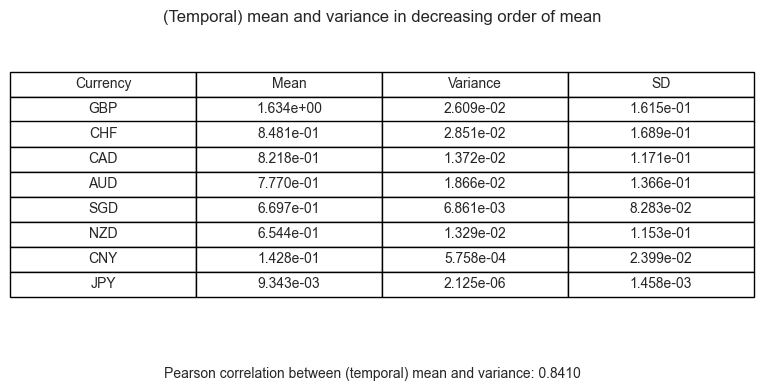

In [107]:
"""
Mean, Variance
"""

from scipy.stats import pearsonr


#------------------# computing means and variance #------------------#
dim = 8
mean_list, var_list = np.zeros(dim), np.zeros(dim)
for j in range(dim):
    mean_list[j] = np.mean(data[:, j])
    var_list[j] = np.var(data[:, j])
order = np.argsort(mean_list)[::-1]

table_data = []
for j in order:
    table_data.append([labels[j], f"{mean_list[j]:.3e}", f"{var_list[j]:.3e}", f"{np.sqrt(var_list)[j]:.3e}"])
column_names = ["Currency", "Mean", "Variance", "SD"]
#--------------------------------------------------------------------#


#------------------------------# plot #------------------------------#
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('tight')
ax.axis('off')  # Hide the axes since we only want the table

# Generate the table
the_table = ax.table(cellText=table_data,colLabels=column_names,loc='center',cellLoc='center')
the_table.scale(1.2, 1.5)

plt.title('(Temporal) mean and variance in decreasing order of mean')
plt.savefig('table_plot.png', bbox_inches='tight')

plt.figtext(0.5, 0.01, f"Pearson correlation between (temporal) mean and variance: {pearsonr(mean_list, var_list)[0]:.4f}",  ha="center")
plt.show()
#--------------------------------------------------------------------#

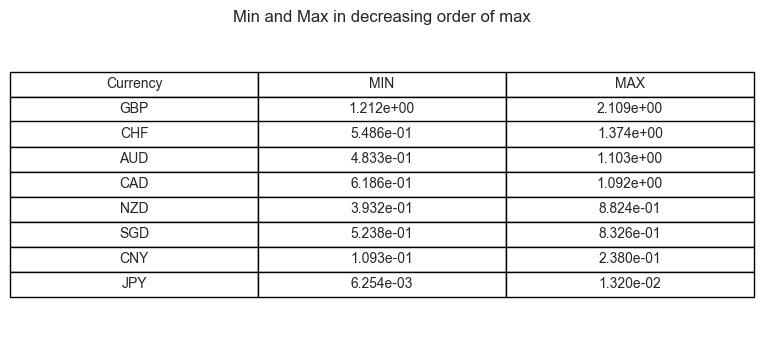

In [108]:
"""
min, max
"""

#---------------------# computing min and max #---------------------#
min_list, max_list = np.zeros(dim), np.zeros(dim)
for j in range(dim):
    min_list[j] = np.min(data[:, j])
    max_list[j] = np.max(data[:, j])
order = np.argsort(max_list)[::-1]
table_data = []
for j in order:
    table_data.append([labels[j], f"{min_list[j]:.3e}", f"{max_list[j]:.3e}"])
#--------------------------------------------------------------------#



#------------------------------# plot #------------------------------#
column_headers = ["Currency", "MIN", "MAX"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=table_data,colLabels=column_headers,loc='center',cellLoc='center')
table.scale(1.2, 1.5)

plt.title('Min and Max in decreasing order of max')
plt.savefig('table_plot.png', bbox_inches='tight')
#--------------------------------------------------------------------#

**Skewness, kurtosis**

*Skewness:* standardized (i.e., normalized by the variance^3) third central (i.e., the mean is substracted) moment of a random variable. It measures asymmetry, and should be about zero for samples drawn from a normal distribution

*Kurtosis:* standardized fourth moment. While variance measures fluctuations, kurtosis measures the prevalence of extreme events as extreme values are amplified by the exponent 4.

*Return:* $R = ( V_{i+1} - V_i ) / V_i$ where $V_i$ is the raw value. However, the log return is usually defined just as $R_{log} = \log \left(V_{i+1} / V_i \right) = \log V_{i+1} - \log V_i$

In [109]:
from scipy.stats import skew, kurtosis

returns = np.diff(np.log(data), axis=0)
# because we consider time series where the distribution at a given point in time may be different that at another time point (=no stationarity), we look at the (log) return instead.

#--------------------------# calculation #--------------------------#
dim = 8
skew_list = np.zeros(dim)
kurt_list = np.zeros(dim)
for j in range(dim):
    x = returns[:, j]
    skew_list[j] = skew(x)
    kurt_list[j] = kurtosis(x, fisher=True)
#--------------------------------------------------------------------#


#------------------------------# print #-----------------------------#
order = np.argsort(skew_list)[::-1]

print('Skewness (column 1) and kurtosis (column 2) in decreasing order of skewness:')
for j in order:
    print(f"{labels[j]} skew={skew_list[j]:.3f} kurt={kurt_list[j]:.3f}")

print('')
print('Pearson correlation between skewness and kurtosis: ' + str(pearsonr(skew_list, kurt_list)[0]))
#--------------------------------------------------------------------#

Skewness (column 1) and kurtosis (column 2) in decreasing order of skewness:
JPY skew=0.683 kurt=29.464
CHF skew=0.548 kurt=41.637
CAD skew=0.336 kurt=83.075
SGD skew=0.158 kurt=172.028
NZD skew=-0.574 kurt=18.012
GBP skew=-0.610 kurt=31.614
AUD skew=-0.660 kurt=59.352
CNY skew=-14.410 kurt=1837.393

Pearson correlation between skewness and kurtosis: -0.9897646222415941


*Conclusion:* small skew and huge kurtosis (i.e., heavy tails), except for CNY that has a weird behavior with heavily negative tails and massive negative skewness. Seems not Gaussian.

**Rolling STD**

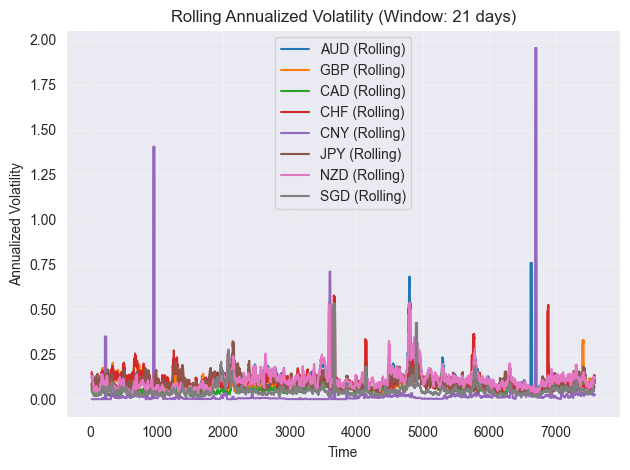

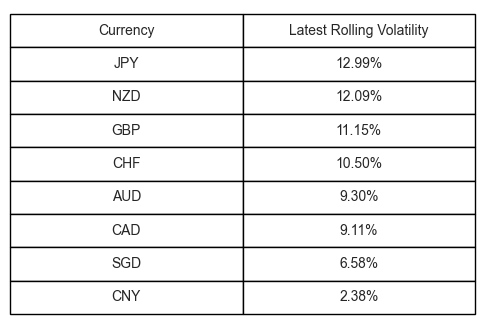

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#--------------------------# rolling STD #--------------------------#
window_size = 21  # Approx 1 trading month
trading_days = 252

df_prices = pd.DataFrame(data, columns=labels)
log_returns = np.log(df_prices).diff()
# compute something over a window preceding the current value:
rolling_std = log_returns.rolling(window=window_size).std()
# projected annual volatility given the daily standard deviation computed across a given time window:
rolling_ann_vol = rolling_std * np.sqrt(trading_days) # See below some notes about the definition of volatility
#--------------------------------------------------------------------#


#------------------------------# plot #------------------------------#
plt.figure()
for label in labels:
    plt.plot(rolling_ann_vol[label], label=f"{label} (Rolling)")

plt.title(f"Rolling Annualized Volatility (Window: {window_size} days)")
plt.xlabel("Time")
plt.ylabel("Annualized Volatility")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

latest_vol = rolling_ann_vol.iloc[-1] # return last volatility value of each currency
order = np.argsort(latest_vol)[::-1]
vol_table_data = [[labels[i], f"{latest_vol.iloc[i]:.2%}"] for i in order if not np.isnan(latest_vol.iloc[i])]

# Plotting the Comparison Table for Current Volatility
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=vol_table_data, colLabels=["Currency", "Latest Rolling Volatility"], loc='center', cellLoc='center')
table.scale(1, 2)
plt.show()
#--------------------------------------------------------------------#

---

**Stationarity**

We want to check stationarity

_Augmented Dickey–Fuller test or ADF (https://en.wikipedia.org/wiki/Augmented_Dickey–Fuller_test):_
low p-value is evidence to reject the null hypothesis that states that there is no stationary'.

_Kwiatkowski–Phillips–Schmidt–Shin test or KPSS (https://en.wikipedia.org/wiki/KPSS_test):_
low p-value is evidence to reject the null hypothesis that states that there is stationarity.

In [111]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

print("Exchange rates")

for j,l in enumerate(labels):
        print(f"{l} ADF p={adfuller(data[:,j], autolag='AIC')[1]:.5e}", f", KPSS p={kpss(data[:,j], regression='c', nlags='auto')[1]:.5e}")
"""
• autolag="AIC" Automatically choose the number of lagged differences p that minimizes the Akaike Information Criterion (AIC).
• a lag is how many past time steps are explicitly accounted for in the test
• regression='c' means that we test stationary around a constant mean
• nlags='auto' means Automatically select the truncation lag using a data-driven rule (usually based on sample size).
"""

print('')
print("Returns")

for j,l in enumerate(labels):
    print(f"{l} ADF p={adfuller(returns[:,j], autolag='AIC')[1]:.5e}", f", KPSS p={kpss(returns[:,j], regression='c', nlags='auto')[1]:.5e}")


Exchange rates
AUD ADF p=4.49233e-01 , KPSS p=1.00000e-02
GBP ADF p=2.24998e-01 , KPSS p=1.00000e-02
CAD ADF p=6.04791e-01 , KPSS p=1.00000e-02
CHF ADF p=4.90267e-01 , KPSS p=1.00000e-02
CNY ADF p=4.90519e-02 , KPSS p=1.00000e-02
JPY ADF p=2.36501e-01 , KPSS p=1.00000e-02
NZD ADF p=4.16646e-01 , KPSS p=1.00000e-02
SGD ADF p=4.06701e-01 , KPSS p=1.00000e-02

Returns
AUD ADF p=0.00000e+00 , KPSS p=1.00000e-01
GBP ADF p=0.00000e+00 , KPSS p=1.00000e-01
CAD ADF p=0.00000e+00 , KPSS p=1.00000e-01
CHF ADF p=0.00000e+00 , KPSS p=1.00000e-01
CNY ADF p=0.00000e+00 , KPSS p=5.28457e-02
JPY ADF p=0.00000e+00 , KPSS p=1.00000e-01
NZD ADF p=0.00000e+00 , KPSS p=1.00000e-01
SGD ADF p=0.00000e+00 , KPSS p=1.00000e-01


*Conclusion:* We can safely reject stationarity assumption for raw exchange rates.
However, it is fair to conclude that returns are stationary.

---

**Volatility**

We assume that prices follow a random walk $dP_t = \mu P_t dt + \sigma P_t W_t$ (geometric noise)
where $\sigma$ is the annual volatility, which can be expressed as the $\text{daily STD} \times \sqrt{\text{number of days}}$

_Proof:_
Consider the return over $N$ days as the sum of daily returns adding up: $R_N = \sum_{t=1}^N r_t$.
Denoting the mean of $R_N$ by $\mu$, the standard deviation of $R_N$ then becomes $\sigma_N = \sqrt{\mathrm{E}\left[\left(\sum_{t=1}^N r_t - \mu\right)^2\right]}$. If $r_i$ are assumed independent across all $i$, and denoting their mean $\mu_r$, then $\mu = N \mu_r$ and we can write $\sigma_R^2 = \left(\sum_{t=1}^N r_t - \mu\right)^2 = \sum_{t=1}^N \sum_{t'=1}^N (r_t - \mu_r)(r_{t'} - \mu_r)$
 $\Rightarrow \mathrm{E}\left[\left(\sum_{t=1}^N r_t - \mu\right)^2\right] = \sum_{t \neq t'}^N \ \mathrm{E}\left[  (r_t - \mu_r)(r_{t'} - \mu_r)\right] + \sum_{t = t'}^N \mathrm{E}\left[  (r_t - \mu_r)^2\right] = N \sigma_r^2 $
$\Rightarrow \sigma_R = \sqrt{N} \sigma_r$. QED

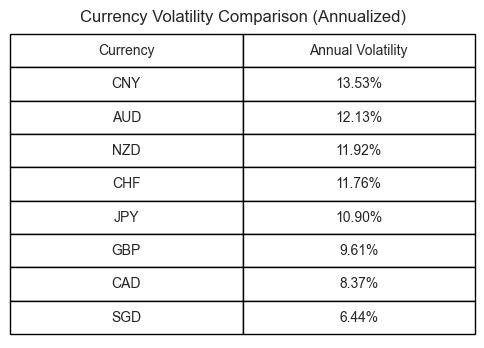

In [112]:
#----------------------# Computing volatility #----------------------#
log_returns = np.diff(np.log(data), axis=0)
ann_vol = np.std(log_returns, axis=0, ddof=1) * np.sqrt(252) # we assume 252 trading days
order = np.argsort(ann_vol)[::-1]
vol_data = [[labels[i], f"{ann_vol[i]:.2%}"] for i in order]
#--------------------------------------------------------------------#


#------------------------------# plot #------------------------------#
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=vol_data, colLabels=["Currency", "Annual Volatility"], loc='center', cellLoc='center')
table.scale(1, 2)
plt.title("Currency Volatility Comparison (Annualized)")
plt.show()
#--------------------------------------------------------------------#

---

**risk-return relationship**

A question would be: across those currencies, does high (positive) return is associated with high volatility, a "yes" meaning a positive risk/return relationship as volatility means uncertainty (high risk high reward)?

We compute the _Sharpe ratio_ that is basically the mean annual return over the volatility. For an investor, the larger it is, the better.

In [113]:
mean_daily = returns.mean(axis=0)
vol_daily  = returns.std(axis=0, ddof=1)
mean_annual = mean_daily * 252
vol_annual  = vol_daily * np.sqrt(252)

sharpe = mean_annual / vol_annual

print("Sharpe ratios (annualized):")
for lbl, s in zip(labels, sharpe):
    print(f"{lbl}: {s:.3f}")

Sharpe ratios (annualized):
AUD: -0.024
GBP: -0.092
CAD: -0.058
CHF: 0.123
CNY: -0.094
JPY: 0.068
NZD: 0.043
SGD: 0.141


---

**Volatility clustering**

_Some reminders and definitions:_

Price $V_t$

Simple return $R_t = (V_t - V_{t-1}) / V_{t-1}$

Log return $r_t = \log V_t / V_{t-1}$

Absolute log return $|r_t|$

Volatility clustering as autocorrelation of the absolute log return: $\text{corr}(|r_t|, |r_{t-1}|)$. Volatility doesn't appear in this definition but, implicitely dropping the stationary hypothesis of returns under which volatility is a fixed parameter, the volatility clustering score indirectly scores the extent to which returns keep their magnitude (absolute value) over time which would suppose, if this is the case, that fluctuations (volatility) remains high, and vice versa.

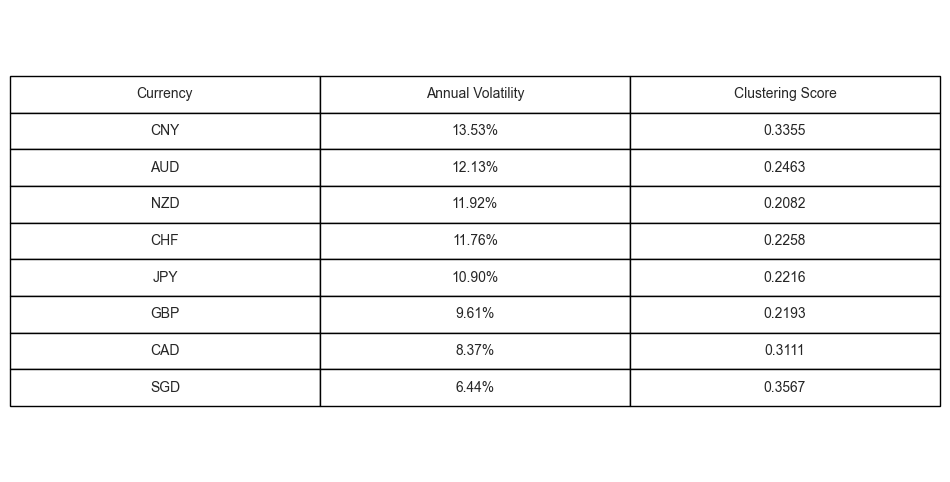

Correlation between volatility and clustering score: -0.4110


In [114]:
#----------------# Computing volatility clustering #-----------------#
num_days, num_assets = log_returns.shape
clustering_scores = []
for j in range(num_assets):
    absolute_log_return = np.abs(log_returns[:, j])
    score, _ = pearsonr(absolute_log_return[1:], absolute_log_return[:-1])
    clustering_scores.append(score)
order = np.argsort(ann_vol)[::-1]
#--------------------------------------------------------------------#


#---------------------------# printing #-----------------------------#
table_data = []
for j in order:
    table_data.append([labels[j], f"{ann_vol[j]:.2%}", f"{clustering_scores[j]:.4f}"])

column_headers = ["Currency", "Annual Volatility", "Clustering Score"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight'), ax.axis('off')

the_table = ax.table(cellText=table_data, colLabels=column_headers, loc='center', cellLoc='center')

the_table.scale(1.2, 2.2)

plt.show()


cl_corr, _ = pearsonr(ann_vol, clustering_scores)
print(f"Correlation between volatility and clustering score: {cl_corr:.4f}")
#--------------------------------------------------------------------#

An anticorrelation between volatility and clustering intensity would indicate that risk tends to not be persistent as high volatility would tend to be associated with a small volatility clustering score and vice versa.

---

**Correlation matrix of returns**

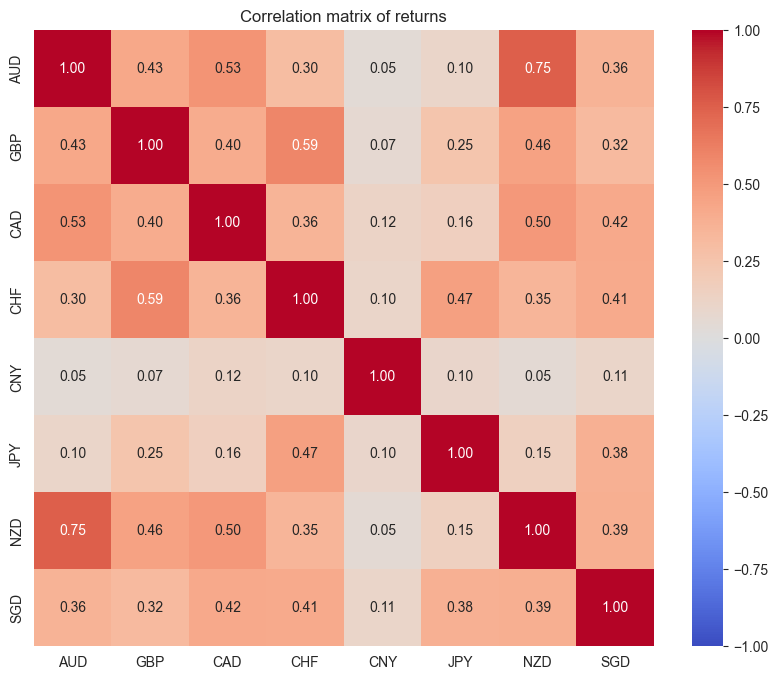

In [115]:
import seaborn as sns

log_returns_dataframe = pd.DataFrame(log_returns, columns=labels)
corr_matrix = log_returns_dataframe.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,  annot=True,       # display values within cells
     fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Correlation matrix of returns")
plt.show()

Some currencies' returns are uncorrelated to other ones as CNY while other exhibits substantially higher levels of correlations as AUD whose correlation with GBP is 0,43. This may be explained by shared systematic drivers or/and that they are exposed to similar macroshock (=events), etc.

---

**PCA**

The correlation matrix encodes pairwise co-movements, while PCA reveals the global low-dimensional structure of the whole movement — i.e. how many independent collective modes actually drive the system and how much redundancy do these assets display.

currencies can be viewed as the features and time stamps as data points.

We compute the covariance matrix whose eigenvectors indicate the directions of maximum variance. Technically, we solve $Σv_j=λ_jv_j$ where Σ is the covariance matrix, $v_j$ the jth eigenvector and $λ_j$ its corresponding eigenvalue.

If the data is normalized (unit variances along directions within feature space), the variance along some direction $v_j$ (so the variance of the projection of the data $X$ onto direction $v$, i.e. $v^TX$) corresponds can be expressed as $\text{Var}_{\text{proj}} = v_j^T Σ v_j = v_j^T λ_j v_j = λ_j$ QED
$\rightarrow$ The variances along the $v_j$ ARE the eigenvalues so that we can see those directions as explaining a certain amount of variance, or fraction $= λ_j / (\sum_k λ_k)$.

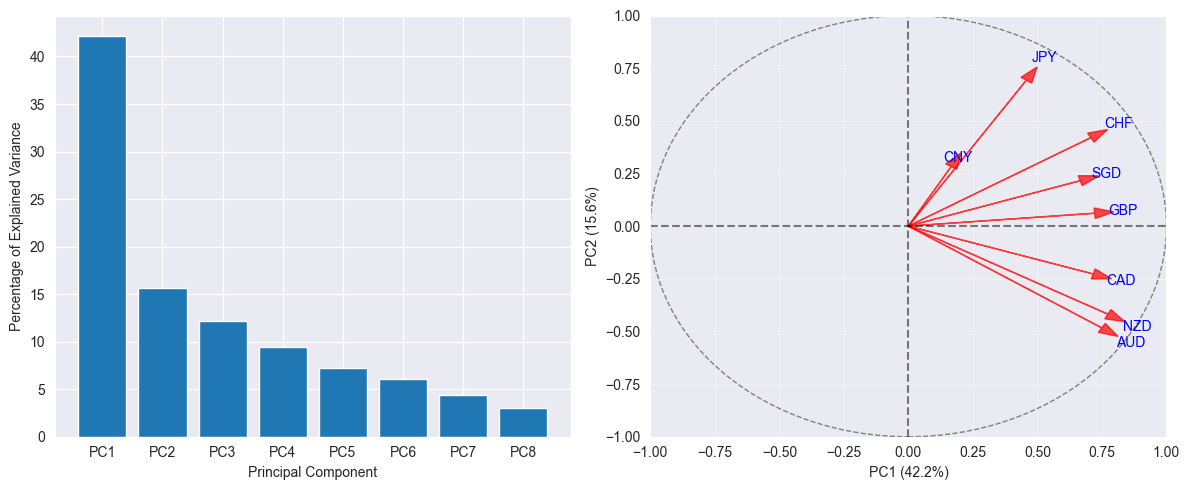

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


#------------------------------# PCA #-------------------------------#
scaler = StandardScaler()
X_scaled = scaler.fit_transform(log_returns_dataframe.dropna())
# <.dropna> removes every time row that contains at least one missing value (NaN)
# fit_transform can be viewed as a function computing the right stuff ("fit") and using it to perform the right transformation ("transform"); here, it computes the means and variances in order to standardize the data

pca = PCA()
pca_data = pca.fit_transform(X_scaled) # projection of data into eigenvectors
labels = log_returns_dataframe.columns
#--------------------------------------------------------------------#

#-----------------------------# plot #-------------------------------#
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
plt.bar(np.linspace(1,len(per_var), len(per_var)), height=per_var, tick_label=[f'PC{i}' for i in range(1,len(per_var)+1)])
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
#plt.title('Scree Plot')



# correlation circle
plt.subplot(1, 2, 2)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
"""
Some technical notes for myself:
 pca.components_.T's columns are the eigenvectors (v1, v2, ...).
 loadings scale them with the stretch of the data (SD along eigenvectors)
 warning: * is not matrix multiplication, it's basically an element-wise multiplication which, here, multiplies each element of the left factor (ith component of jth eigenvector that is the jth column) by the (jth) sqrt(eigenvalue)
 so that loadings is a (nfeature, ncomponents) matrix

 Statistical Meaning of loadings: it can be shown that Loading_ij = v_ij sqrt(lambda_j) = corr(Xi, PCj).
 --> CORRELATION between original feature 'i' and principal component 'j'.
where here the jth principal components is not used as synonymous for jth eigenvector, but designates the projection of the data along the (jth) eigenvector
This correlation (or simply covariance if the data is not standardized) answers: "How does data points of this feature do contribute to this direction?"
"""


plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.axvline(0, color='k', linestyle='--', alpha=0.5)

# Tracer les vecteurs
for i in range(len(labels)):
    # how much the ith feature contributes to the first 2 eigenvectors (whether feature direction align with them, first, and also vary along this direction), each component being the correlation between feature i and the projection of feature i along each of those directions
    # the entry i,j fully depends on the ith component of the jth eigenvector so that the corresponding entry of loadings is small if this feature direction doesn't align significantly with the jth eigenvector
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, labels[i], color='b', ha='center', va='center')

circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

plt.xlabel(f'PC1 ({per_var[0]}%)')
plt.ylabel(f'PC2 ({per_var[1]}%)')
#plt.title('Correlation circle')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#--------------------------------------------------------------------#


---

**Gradient boosting**

We consider volatility over time (the momentary volatility is computed via the daily SD computed over a time window preceding the current point). And we ask: can we predict if the future market volatility be explained based on known top components ? (PCA + ML pipeline)

Wikipedia:
"In machine learning (ML), boosting is an ensemble learning method that combines a set of less accurate models (called "weak learners") to create a single, highly accurate model (a "strong learner")."

Let us say that we want to fit some data by minimizing the mean square error $= \mathrm{E}\left[\left(\hat{y_i} - y_i\right)^2\right]$ where $\hat{y_i}$ is the prediction and $y_i$ the true observation. In usual optimization setup, we work in parameter state space as we aim to optimize parameter values of a function. In gradient boosting, we work in function state space as, at each state of the optimization process, we decide to add a term to the function (i.e., gradient descent on function space). Given M models, and given $F_m(x_i)$ the prediction of model $m$ regarding observation $x_i$, at stage $m+1$, we optimize the "residual" $h_m(x_i) = y_i - F_m(x_i)$. In fact, $h_m$ are regression trees (i.e., at each root node, we answer is it larger or smaller than this number, etc. Ex. if inferior to 10 add +6, otherwize -6, and this determines the value of the constant we add to the function). More technically, in a tree regression is basically growing a tree until the tree yields values of ri that makes L decrease sufficiently given some criterion.

Regression trees are super easy but quite sloppy and the idea of boosting tree is to do it iteratively. Boosting trees output piecewise constant approximation.
Regression trees are super easy but quite sloppy and the idea of Gradient tree boosting is to do it iteratively.

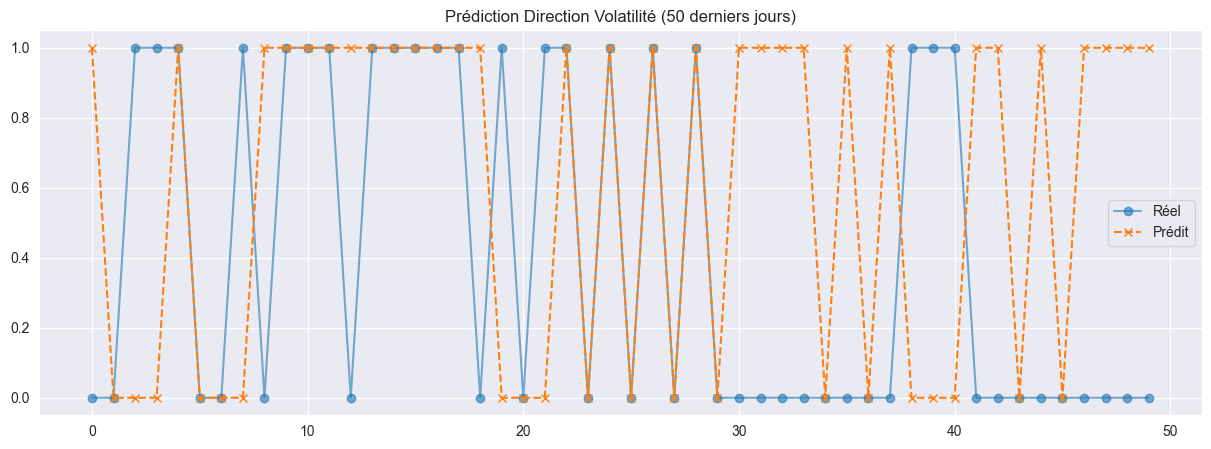


--- RAPPORT DE PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.54      0.59      0.56       805
           1       0.48      0.43      0.45       709

    accuracy                           0.51      1514
   macro avg       0.51      0.51      0.51      1514
weighted avg       0.51      0.51      0.51      1514



In [117]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier # LE SAUVEUR
from sklearn.metrics import classification_report, accuracy_score



#------------------------------# PCA #-------------------------------#
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(log_returns)
pca = PCA(n_components=None) # "n_components=None" means that we don't drop any dimensions
pca_data = pca.fit_transform(scaled_returns)
explained_var = pca.explained_variance_ratio_

window = 21
pc1_vol = pd.Series(pca_data[:, 0]).rolling(window).std()
# whole history of first component For every value, we look at a window before and compute a SD, so it yields NaN until the window-th value
#--------------------------------------------------------------------#


#-------------------------# Preliminaries #--------------------------#
df_ml = pd.DataFrame(pca_data[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_ml['Vol_PC1'] = pc1_vol
df_ml['Target'] = (pc1_vol.shift(-1) > pc1_vol).astype(int)
# pc1_vol.shift(-1) shifts by -1; i.e., pc1_vol.shift(-1)[k] = pc1_vol[k+1]
# we systemetically compare whether tomorrow is larger than today and replace the boolean values by 0 and 1
# 4 days of memory
for i in range(1, 4):
    df_ml[f'PC1_lag{i}'] = df_ml['PC1'].shift(i)
df_ml.dropna(inplace=True) # we remove the lines where there are some NaN values
split = int(len(df_ml) * 0.8) # we split the data to have training data vs testing data
X = df_ml.drop('Target', axis=1) # everything but the Target column, so everything used to predict the target
y = df_ml['Target']
X_train, X_test = X.iloc[:split], X.iloc[split:] # iloc is the way you slice dataframe objects
y_train, y_test = y.iloc[:split], y.iloc[split:]
#--------------------------------------------------------------------#

#-------------------------# Preliminaries #--------------------------#
model = HistGradientBoostingClassifier(max_iter=100, max_depth=3)#, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
#--------------------------------------------------------------------#


#--------------------------# plot / print #--------------------------#
plt.figure(figsize=(15, 5))

plt.plot(y_test.values[:50], 'o-', label="Réel", alpha=0.6)
plt.plot(y_pred[:50], 'x--', label="Prédit")
plt.title("Prédiction Direction Volatilité (50 derniers jours)")
plt.legend()

plt.show()

print("\n--- RAPPORT DE PERFORMANCE ---")
print(classification_report(y_test, y_pred))
#--------------------------------------------------------------------#

---

**Time-series forecasting using LSTM neural networks**

This following code implements a Time-Series Forecasting model using a Deep Learning architecture called LSTM (Long Short-Term Memory). Specifically, it tries to predict the future returns of a currency based on the past data.

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


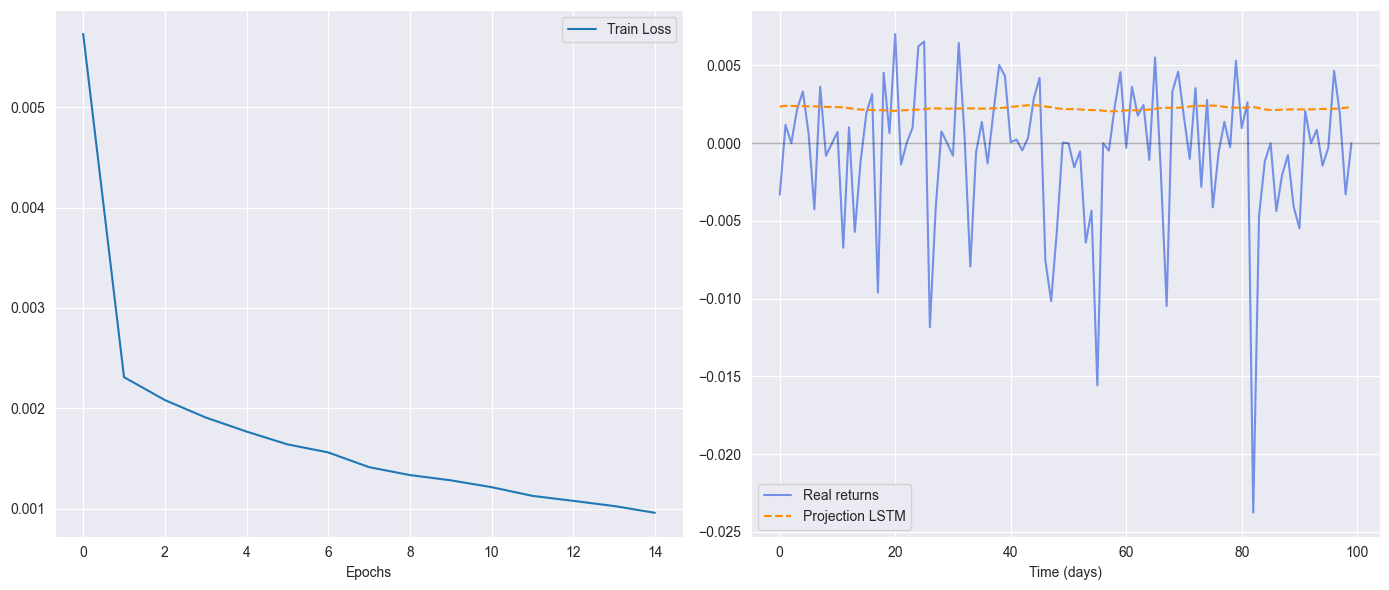

Return sign accuracy: 44.05%


In [118]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

warnings.filterwarnings("ignore", category=FutureWarning)

log_returns_df = pd.DataFrame(log_returns)
scaled_data = scaler.fit_transform(log_returns_df.dropna())

#------------------------# data preparation #------------------------#
scaler = MinMaxScaler(feature_range=(0, 1)) # scaled x = (x-MIN(x)) / (MAX(x) - MIN(x))
"""
standardization can mean setting the variance and mean to 1 and 0, respectively. However, in Deep Learning, depending on the activation function at play, using the standard standardization can potentially make the input ranging form -in to +inf where the activation function is blind assuming that the step is essentially between 0 and 1, which is not interesting
"""
scaled_data = scaler.fit_transform(log_returns_df.dropna())

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length]) # from a data window
        y.append(data[i+seq_length, 0]) # we predict the future of the first currency
    return np.array(X), np.array(y)

SEQ_LENGTH = 30
X, y = create_sequences(scaled_data, SEQ_LENGTH)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
#--------------------------------------------------------------------#



#------------------------# Setting up the model #------------------------#
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])), # tells the model the structure of the input
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50),
    Dropout(0.2),
    Dense(units=1)
])

"""
model = Sequential([
    Input(...),            # Input
    LSTM(...),             # Layer 1 (Hidden)
    Dropout(...),          # Layer 2 (Regularization layer)
    LSTM(...),             # Layer 3 (Hidden)
    Dropout(...),          # Layer 4 (Regularization layer)
    Dense(...)             # Layer 5 (Output)
])

regularization layers prevent overfitting:
If you have Dropout(0.2), the layer randomly "kills" 20% of the values flowing through it during each training iteration. If a neuron is randomly turned off (set to zero) during a training round, the model is still forced to try and predict the output so that it learns how to generate correct answers without relying too much on specific neurons that may individually overfit some data versus ensemble of (independent) neurons.

An LSTM unit is essentially made of 4 parallel layers.
Layer 1 (Forget Gate): 50 neurons with Sigmoid activation.
Layer 2 (Input Gate): 50 neurons with Sigmoid activation.
Layer 3 (Candidate Gate): 50 neurons with Tanh activation.
Layer 4 (Output Gate): 50 neurons with Sigmoid activation.

Diverse Perspectives: Each of the 50 units will initialize with different random weights.
"""

model.compile(optimizer='adam', loss='mean_squared_error')
"""
If the Loss tells the model it is "wrong," the Optimizer tells it "how to change the weights to become right."

Adam (Adaptive Moment Estimation) is the most popular optimizer in Deep Learning because it is smart and fast. Think of it as Gradient Descent with an autopilot:

Direction: It calculates the gradient (the slope) to see which way the weights need to move to lower the loss.

Speed (Learning Rate): Unlike basic optimizers, Adam maintains a separate learning rate for every single weight in your LSTM.

Momentum: If it's been moving in one direction for a while, it gains "momentum," helping it sail past small bumps in the data to find the true mathematical minimum.
"""
#--------------------------------------------------------------------#


#----------------------------# Training #----------------------------#
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.1, verbose=0)
#--------------------------------------------------------------------#


#-----------------------------# Testing #----------------------------#
predictions_scaled = model.predict(X_test)

# We want to undo the scaling (see data preparation above)
# We create an empty matrix because the function "scaler.inverse_transform" expects a 8 columns matrix
dummy = np.zeros((len(predictions_scaled), scaled_data.shape[1]))
dummy[:, 0] = predictions_scaled.flatten() # Bevause the LSTM's predictio output has a 2D shape like: [[0.5], [0.6], [0.4]]
predictions = scaler.inverse_transform(dummy)[:, 0]

dummy_real = np.zeros((len(y_test), scaled_data.shape[1]))
dummy_real[:, 0] = y_test
real_values = scaler.inverse_transform(dummy_real)[:, 0]
#--------------------------------------------------------------------#



#-------------------------------# Plot #-----------------------------#
plt.figure(figsize=(14, 6))

# plotting the loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.xlabel('Epochs')
#plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()

# Projection of the model
plt.subplot(1, 2, 2)
plt.plot(real_values[-100:], label="Real returns", color='royalblue', alpha=0.7)
plt.plot(predictions[-100:], label="Projection LSTM", color='darkorange', linestyle='--')
plt.xlabel('Time (days)')
plt.axhline(0, color='black', lw=1, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


direction_accuracy = np.mean(np.sign(predictions) == np.sign(real_values))
print(f"Return sign accuracy: {direction_accuracy:.2%}")
#--------------------------------------------------------------------#

I would say that regarding the question of when to use deep learning versus gradient boosting or any other sort of methods really depends on the question we aim to address, on the structure of the data, and many other things. Experience is key.